           family      metric      mean       sem   n
0   CorePeriphery   SB_over_k  0.907292  0.004754  60
1   CorePeriphery   SE_over_k  0.810937  0.005774  60
2   CorePeriphery   BE_over_k  0.797396  0.006236  60
3   CorePeriphery  SBE_over_k  0.756250  0.006718  60
4   CorePeriphery        dens  0.017810  0.000072  60
5   CorePeriphery       sigma  0.226766  0.011550  60
6             SBM   SB_over_k  0.480729  0.009744  60
7             SBM   SE_over_k  0.540625  0.017645  60
8             SBM   BE_over_k  0.313021  0.012940  60
9             SBM  SBE_over_k  0.259375  0.012369  60
10            SBM        dens  0.040821  0.000099  60
11            SBM       sigma  2.876939  0.010421  60


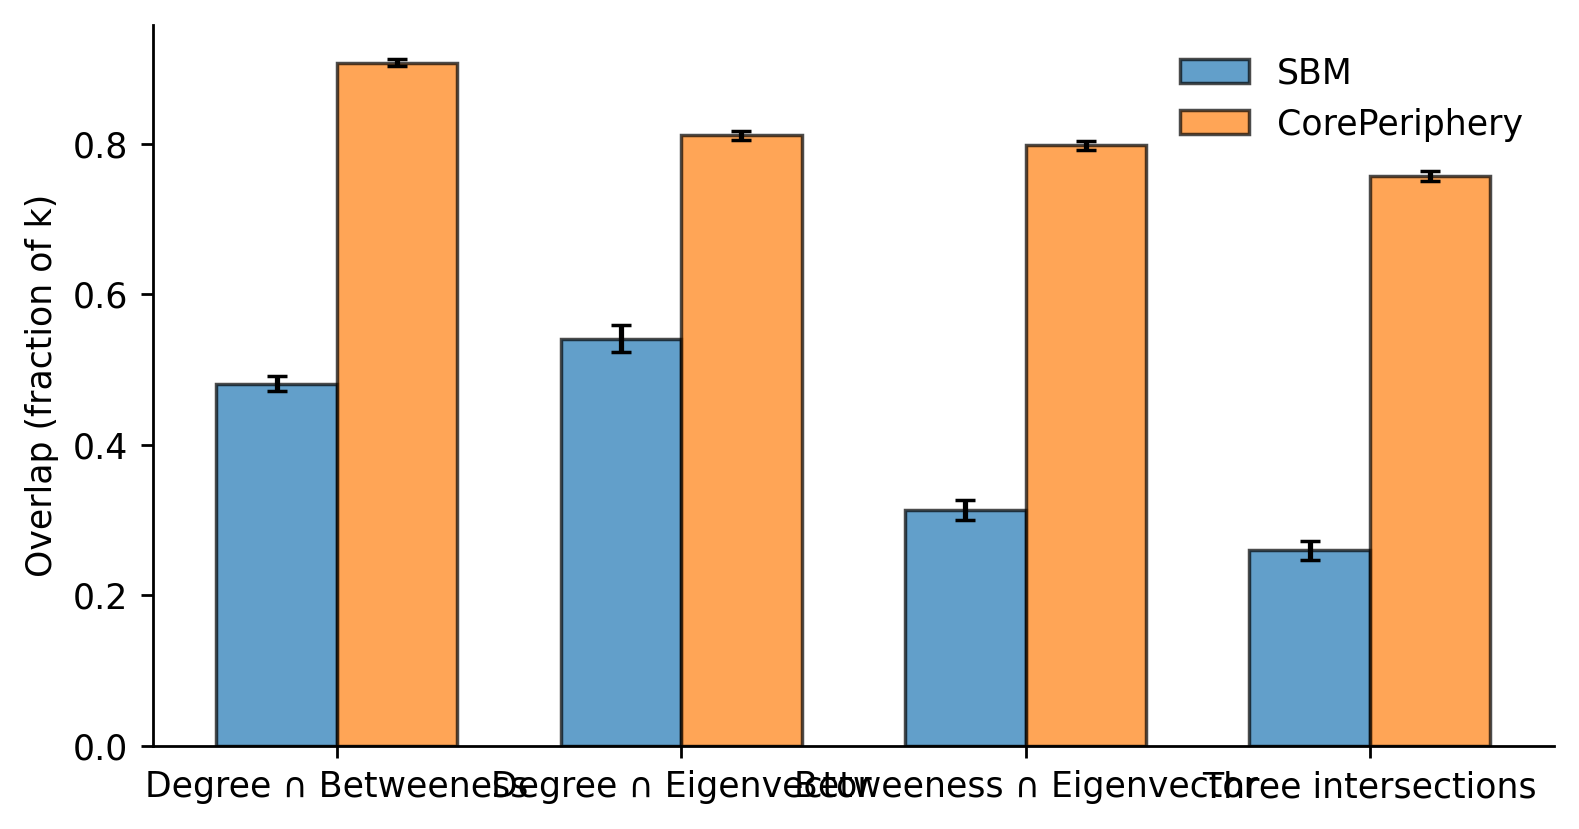

In [12]:
import numpy as np
import pandas as pd
import networkx as nx
import math
import matplotlib.pyplot as plt

# -------------------------
# Helpers: assign weights
# -------------------------
def assign_random_weights(G, low=0.2, high=1.0, seed=0):
    rng = np.random.default_rng(seed)
    for u, v in G.edges():
        G[u][v]["weight"] = float(rng.uniform(low, high))
    return G

# ----------------------------------------
# Centralities + top-k overlaps (your key)
# ----------------------------------------
def overlap_metrics(G, top_frac=0.10):
    n = G.number_of_nodes()
    k = max(1, math.ceil(top_frac * n))

    # Strength (weighted degree)
    strength = dict(G.degree(weight="weight"))

    # Betweenness with distance = 1/weight
    H = G.copy()
    for u, v, d in H.edges(data=True):
        w = float(d.get("weight", 1.0))
        d["distance"] = 1.0 / w if w > 0 else np.inf
    betw = nx.betweenness_centrality(H, weight="distance", normalized=True)

    # Eigenvector (weighted)
    try:
        eig = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        eig = nx.eigenvector_centrality(G, weight="weight", max_iter=2000)

    def topk(d):
        return {node for node, _ in sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]}

    S = topk(strength)
    B = topk(betw)
    E = topk(eig)

    return {
        "N": n,
        "k": k,
        "dens": nx.density(G),
        "SB_over_k": len(S & B) / k,
        "SE_over_k": len(S & E) / k,
        "BE_over_k": len(B & E) / k,
        "SBE_over_k": len(S & B & E) / k,
    }

# ----------------------------------------
# OPTIONAL: small-world sigma (quick proxy)
# ----------------------------------------
def small_world_sigma_quick(G, n_rand=30, seed=0):
    """
    Lightweight sigma: compares C and L to degree-preserving configuration-model null.
    Intended for simulation intuition, not a heavy publication-grade SW pipeline.
    """
    rng = np.random.default_rng(seed)

    if G.number_of_edges() == 0:
        return np.nan

    # largest connected component
    if not nx.is_connected(G):
        Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    else:
        Gc = G.copy()

    # C_emp
    C_emp = nx.average_clustering(Gc, weight="weight")

    # L_emp via distance=1/weight
    H = nx.Graph()
    H.add_nodes_from(Gc.nodes())
    for u, v, d in Gc.edges(data=True):
        w = float(d.get("weight", 1.0))
        if w > 0:
            H.add_edge(u, v, distance=1.0 / w)
    try:
        L_emp = nx.average_shortest_path_length(H, weight="distance")
    except Exception:
        return np.nan

    deg_seq = [d for _, d in Gc.degree()]
    weights = np.array([d["weight"] for _, _, d in Gc.edges(data=True)], dtype=float)
    if len(weights) == 0:
        return np.nan

    C_rands, L_rands = [], []
    for _ in range(n_rand):
        R = nx.configuration_model(deg_seq, seed=int(rng.integers(1_000_000_000)))
        R = nx.Graph(R)
        R.remove_edges_from(nx.selfloop_edges(R))
        if R.number_of_edges() == 0:
            continue

        # resample weights
        rand_ws = rng.choice(weights, size=R.number_of_edges(), replace=True)
        for (u, v), w in zip(R.edges(), rand_ws):
            R[u][v]["weight"] = float(w)

        if not nx.is_connected(R):
            Rc = R.subgraph(max(nx.connected_components(R), key=len)).copy()
        else:
            Rc = R

        C_r = nx.average_clustering(Rc, weight="weight")

        Hr = nx.Graph()
        Hr.add_nodes_from(Rc.nodes())
        for u, v, d in Rc.edges(data=True):
            w = float(d.get("weight", 1.0))
            if w > 0:
                Hr.add_edge(u, v, distance=1.0 / w)
        try:
            L_r = nx.average_shortest_path_length(Hr, weight="distance")
        except Exception:
            continue

        C_rands.append(C_r); L_rands.append(L_r)

    if len(C_rands) == 0 or len(L_rands) == 0:
        return np.nan

    C_rand = float(np.mean(C_rands))
    L_rand = float(np.mean(L_rands))
    if C_rand <= 0 or L_rand <= 0:
        return np.nan
    return (C_emp / C_rand) / (L_emp / L_rand)

# -------------------------
# Graph family generators
# -------------------------
def gen_sbm(n_blocks=4, block_size=80, p_in=0.15, p_out=0.01, seed=0):
    sizes = [block_size] * n_blocks
    P = np.full((n_blocks, n_blocks), p_out, float)
    np.fill_diagonal(P, p_in)
    G = nx.stochastic_block_model(sizes, P, seed=seed)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    return assign_random_weights(G, seed=seed)

def gen_core_periphery(n_core=40, n_per=280, p_core=0.02, p_cp=0.08, p_per=0.000, seed=0):
    rng = np.random.default_rng(seed)
    n = n_core + n_per
    G = nx.Graph()
    G.add_nodes_from(range(n))

    core = range(n_core)
    per  = range(n_core, n)

    # core-core
    for i in core:
        for j in range(i + 1, n_core):
            if rng.random() < p_core:
                G.add_edge(i, j)
    # core-periphery
    for i in core:
        for j in per:
            if rng.random() < p_cp:
                G.add_edge(i, j)
    # periphery-periphery
    for i in per:
        for j in range(i + 1, n):
            if rng.random() < p_per:
                G.add_edge(i, j)

    G.remove_edges_from(nx.selfloop_edges(G))
    return assign_random_weights(G, seed=seed)

# -------------------------
# Run simulation
# -------------------------
def run_sim(n_reps=50, top_frac=0.10, with_sigma=False):
    rows = []
    for seed in range(n_reps):
        G_sbm = gen_sbm(seed=seed, p_in=0.15, p_out=0.005, n_blocks=4, block_size=80)  # N=320
        G_cp  = gen_core_periphery(seed=seed, n_core=40, n_per=280)                     # N=320

        r1 = overlap_metrics(G_sbm, top_frac=top_frac); r1["family"] = "SBM"
        r2 = overlap_metrics(G_cp,  top_frac=top_frac); r2["family"] = "CorePeriphery"

        if with_sigma:
            r1["sigma"] = small_world_sigma_quick(G_sbm, n_rand=30, seed=seed)
            r2["sigma"] = small_world_sigma_quick(G_cp,  n_rand=30, seed=seed)

        rows.extend([r1, r2])

    return pd.DataFrame(rows)

df_sim = run_sim(n_reps=60, top_frac=0.10, with_sigma=True)

# -------------------------
# Summary table (mean ± SEM)
# -------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    sem = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return x.mean(), sem

summary_rows = []
for fam, g in df_sim.groupby("family"):
    for col in ["SB_over_k", "SE_over_k", "BE_over_k", "SBE_over_k", "dens", "sigma"]:
        m, se = mean_sem(g[col].values)
        summary_rows.append({"family": fam, "metric": col, "mean": m, "sem": se, "n": len(g)})
df_sim_summary = pd.DataFrame(summary_rows)
print(df_sim_summary)

# -------------------------
# Plot: overlaps comparison
# -------------------------
metrics = ["SB_over_k", "SE_over_k", "BE_over_k", "SBE_over_k"]
labels  = ["Degree ∩ Betweeness", "Degree ∩ Eigenvector", "Betweeness ∩ Eigenvector", "Three intersections"]

x = np.arange(len(metrics))
barw = 0.35

fig, ax = plt.subplots(figsize=(6.2, 3.2), dpi=250, layout="constrained")

for i, fam in enumerate(["SBM", "CorePeriphery"]):
    means = []
    sems = []
    for col in metrics:
        m, se = mean_sem(df_sim[df_sim["family"] == fam][col].values)
        means.append(m); sems.append(se)
    ax.bar(x + (i - 0.5) * barw, means, width=barw, yerr=sems, capsize=3,
           edgecolor="black", linewidth=1, alpha=0.7, label=fam)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Overlap (fraction of k)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.show()

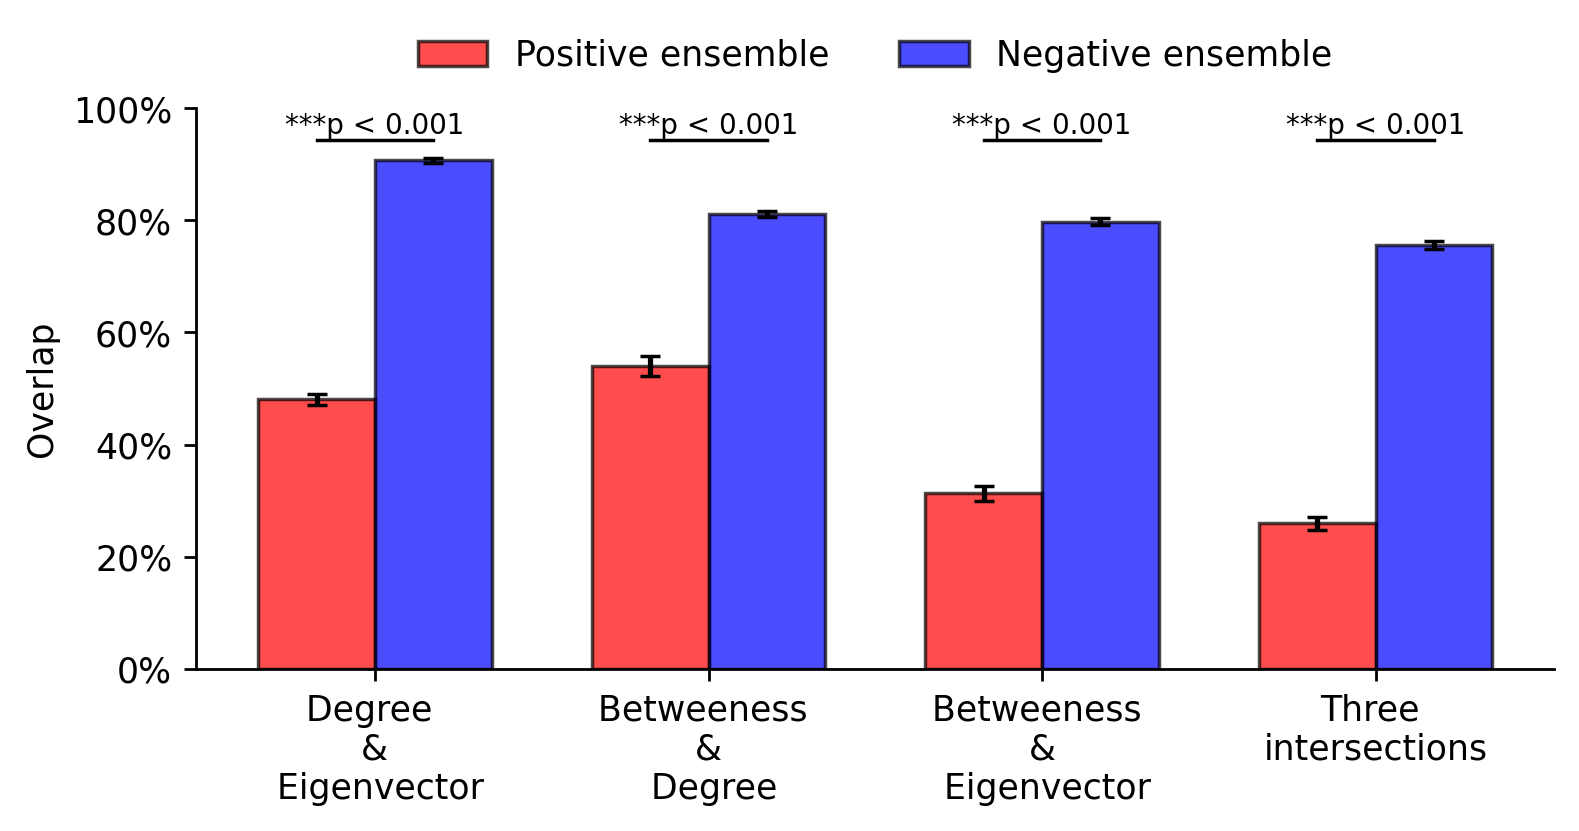

In [18]:
metrics = ["SB_over_k", "SE_over_k", "BE_over_k", "SBE_over_k"]
labels  = ["Degree \n & \n Eigenvector", "Betweeness \n & \n Degree", "Betweeness \n & \n Eigenvector", "Three \nintersections"]

x = np.arange(len(metrics))
barw = 0.35
from scipy.stats import ttest_ind
import numpy as np

def welch_p(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if not np.isfinite(p):
        text = "p = n/a"
    elif p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2)/2, y + h*1.1, text,
            ha="center", va="bottom", fontsize=8)

import matplotlib.ticker as mtick
fig, ax = plt.subplots(figsize=(6.2, 3.2), dpi=250, layout="constrained")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax.set_ylim(0, 1)
for i, (fam, net_type, color) in enumerate(zip(["SBM", "CorePeriphery"], ['Positive ensemble', 'Negative ensemble'], ['red', 'blue'])):
    means = []
    sems = []
    for col in metrics:
        m, se = mean_sem(df_sim[df_sim["family"] == fam][col].values)
        means.append(m); sems.append(se)
    ax.bar(x + (i - 0.5) * barw, means, width=barw, yerr=sems, capsize=3,
           edgecolor="black", linewidth=1, alpha=0.7, label=net_type,facecolor=color)

y_base = 0.8

for idx, col in enumerate(metrics):
    vals_sbm = df_sim[df_sim["family"] == "SBM"][col].values
    vals_cp  = df_sim[df_sim["family"] == "CorePeriphery"][col].values

    p = welch_p(vals_sbm, vals_cp)

    x1 = x[idx] - barw/2
    x2 = x[idx] + barw/2


    add_sig_line(ax, x1, x2, y_base*1.18, 0, p)
    
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=10)
ax.set_ylabel("Overlap ratio")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False,
          loc="upper center",
          bbox_to_anchor=(0.5, 1.18),
          ncol=2)
fig.savefig('simu')
plt.show()

SBM: sigma mean=2.877, sem=0.010, n=60
CorePeriphery: sigma mean=0.227, sem=0.012, n=60


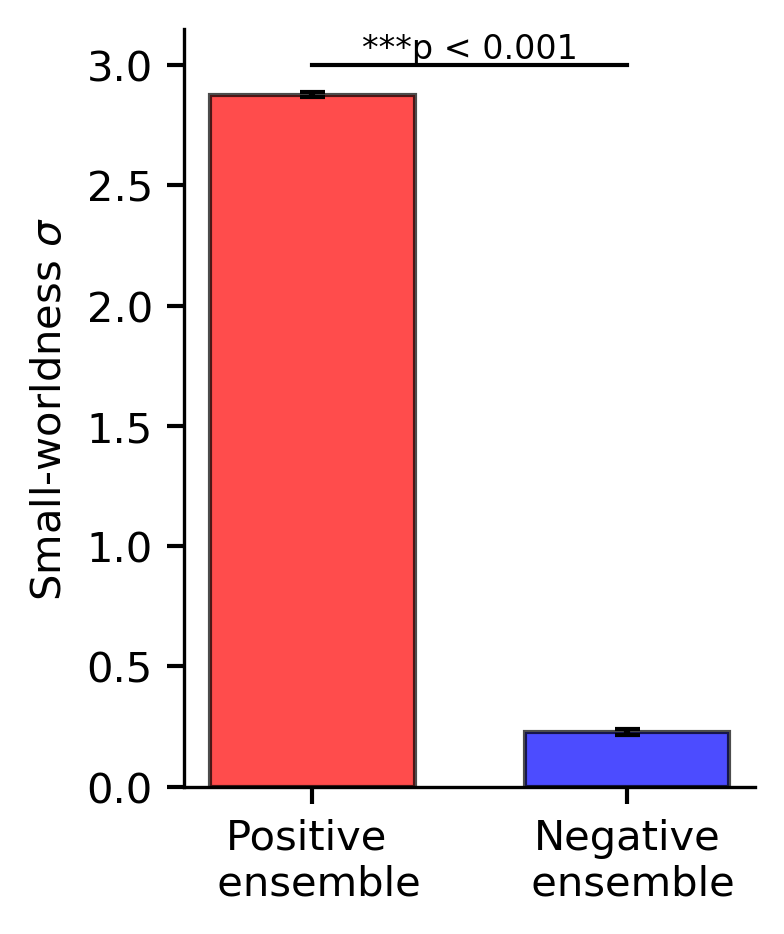

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    sem = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return x.mean(), sem

families = ["SBM", "CorePeriphery"]
color_map = {'SBM': 'red', 'CorePeriphery': 'blue'}
colors = [color_map[c] for c in df_sim['family']]

means = []
sems = []
for fam in families:
    vals = df_sim[df_sim["family"] == fam]["sigma"].values
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)
    print(f"{fam}: sigma mean={m:.3f}, sem={se:.3f}, n={np.isfinite(vals).sum()}")

fig, ax = plt.subplots(figsize=(2.5, 3.0), dpi=300, layout="constrained")
x = np.arange(len(families))

ax.bar(
    x, means, yerr=sems, capsize=3, width=0.65,
    edgecolor="black", linewidth=1, alpha=0.7,facecolor=colors
)

ax.set_xticks(x)
ax.set_xticklabels(['Positive \n ensemble', 'Negative\n ensemble'])
ax.set_ylabel(r"Small-worldness $\sigma$")
## significance bar
sigma_sbm = df_sim[df_sim["family"] == "SBM"]['sigma'].values
sigma_cp  = df_sim[df_sim["family"] == "CorePeriphery"]['sigma'].values

p = welch_p(sigma_sbm, sigma_cp)
x = np.arange(len(families))
x1 = x[0]
x2 = x[1] 
add_sig_line(ax, x1, x2, 3, 0, p)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(length=4, width=1)

plt.show()